# Roman Pointing Tutorial

This notebook demonstrates the Roman Space Telescope pointing model using `unitsConstants.py` instead of `astropy.units`.  
All values are floats and units are handled using constants like `uc.AU`, `uc.parsec`, and `uc.deg`.


In [1]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import SkyCoord, get_body_barycentric, BarycentricMeanEcliptic
import scipy.optimize
from keplertools.angutils import projplane, calcang, rotMat
import unitsConstants as uc

# Nomenclature and Conventions
- **Vectors** are lowercase bold (**v**), unit vectors have hats (**v̂**)
- **Norms** are written ∥**v**∥ such that **v** = ∥**v**∥·**v̂**
- Position vectors follow the notation **r_B/A**, meaning vector from A to B
- **Frames** are calligraphic capitals (e.g., I, B), consisting of an origin and an orthonormal basis
- **DCM** (direction cosine matrix) **BCI** transforms vector components from frame I to frame B
- **Projection** of vector **a** onto a plane orthogonal to **b̂**:
  ```
  a_proj = a - (a · b̂) b̂
  ```

# Reference Frames
- **Inertial Frame I** is the ecliptic barycentric frame: O is solar system barycenter
- Axes: **ê₁** toward vernal equinox, **ê₂** in ecliptic plane, **ê₃** toward ecliptic north
- **Body Frame B** is fixed to Roman: origin at center of mass
- Axes:
  - **x̂**: points along telescope boresight (barrel axis)
  - **ẑ**: orthogonal to solar panels
  - **ŷ**: completes the right-handed set (**ẑ × x̂**)

# Pointing Angles
Roman re-pointing is described by 3 ordered **Euler rotations** about body-fixed axes:
- **Yaw (ψ)**: about **ẑ** (solar panel normal)
- **Pitch (θ)**: about **ŷ**
- **Roll (ϕ)**: about **x̂**
The total orientation change is represented by:
```math
C₁(ϕ) · C₂(θ) · C₃(ψ)
```

# Zero-Point Orientation
At zero-point, Roman’s **ẑ** axis is aligned with the sun vector (**r_⊙/R**):
- Roman initially aligns frame B with frame I
- Then rotates about ŷ by angle **α₁** (to match sun's projection in ê₁-ê₃ plane)
- Then rotates about x̂ by angle **α₂** to fully align **ẑ** with the sun
The zero-point DCM is:
```math
BCI₀ = C₁(α₂) · C₂(α₁)
```

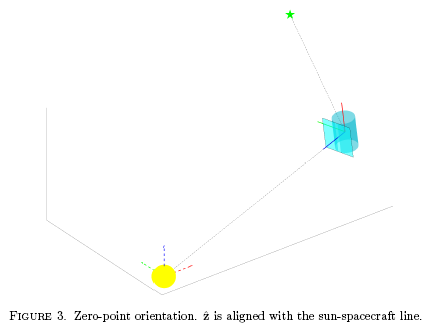

# Target Pointing
- The target direction **r⋆/O** is projected from ICRS coordinates
- The look vector is computed as:
```math
r⋆/G = r⋆/O − rG/O
```
- Yaw (ψ): align x̂ with the projection of look vector onto x̂–ŷ plane
- Pitch (θ): rotate about ŷ to align x̂ with look vector

In [2]:
def compute_L2loc():
    def f(x, mustar):
        return x - (1 - mustar) * (x + mustar) / abs(x + mustar)**3 - mustar * (x - 1 + mustar) / abs(x - 1 + mustar)**3
    mustar_sunearth = 3.003e-6  # Earth / (Earth + Sun)
    return scipy.optimize.fsolve(lambda x: f(x, mustar_sunearth), 1)[0]

L2loc = compute_L2loc()

def getSunPositions(ts):
    sun = SkyCoord(get_body_barycentric("Sun", ts), frame="icrs", obstime=ts).transform_to(BarycentricMeanEcliptic)
    return sun.cartesian.xyz.to_value() * uc.meter

def getL2Positions(ts):
    earth = SkyCoord(get_body_barycentric("Earth", ts), frame="icrs", obstime=ts).transform_to(BarycentricMeanEcliptic)
    return L2loc * earth.cartesian.xyz.to_value() * uc.meter


In [3]:
def calcRomanAngles(target, ts, r_obs_G, r_sun_G=None):
    from astropy.coordinates import SkyCoord, BarycentricMeanEcliptic
    import numpy as np
    import unitsConstants as uc

    # Ensure time arrays are 2D: (3, n)
    if r_obs_G.ndim == 1:
        r_obs_G = r_obs_G[:, np.newaxis]
    if r_sun_G is not None and r_sun_G.ndim == 1:
        r_sun_G = r_sun_G[:, np.newaxis]

    if r_sun_G is None:
        r_sun_G = getSunPositions(ts)

    r_sun_obs = r_sun_G - r_obs_G
    rhat_sun_obs = (r_sun_obs / np.linalg.norm(r_sun_obs, axis=0)).T  # shape (n, 3)

    # Update target for proper motion if available
    try:
        target_updated = target.apply_space_motion(new_obstime=ts)
    except ValueError:
        target_updated = target

    # Default to 1 parsec if no distance
    try:
        distance = target_updated.distance.to_value() * uc.parsec
    except Exception:
        distance = 1 * uc.parsec

    r_target_G = SkyCoord(
        ra=target_updated.icrs.ra,
        dec=target_updated.icrs.dec,
        distance=distance / uc.AU,
        frame="icrs",
        obstime=ts
    ).transform_to(BarycentricMeanEcliptic()).cartesian.xyz.to_value() * uc.meter

    if r_target_G.ndim == 1:
        r_target_G = r_target_G[:, np.newaxis]

    r_target_obs = r_target_G - r_obs_G
    rhat_target_obs = (r_target_obs / np.linalg.norm(r_target_obs, axis=0)).T  # shape (n, 3)

    sun_ang = np.arccos([np.dot(x, y) for x, y in zip(rhat_sun_obs, rhat_target_obs)])

    e2 = np.array([0, 1, 0])
    e3 = np.array([0, 0, 1])

    r_sun_obs_proj1 = projplane(r_sun_obs, e2)
    rhat_sun_obs_proj1 = (r_sun_obs_proj1 / np.linalg.norm(r_sun_obs_proj1, axis=0)).T
    ang1 = np.array([calcang(x, e3, e2) for x in rhat_sun_obs_proj1])
    B_C_I = np.dstack([rotMat(2, -a) for a in ang1])

    b_3 = B_C_I[2, :, :].T
    b_1 = B_C_I[0, :, :].T
    ang2 = np.array([
        calcang(np.asarray(x).flatten(), np.asarray(b3).flatten(), np.asarray(b1).flatten())
        for x, b3, b1 in zip(rhat_sun_obs, b_3, b_1)
    ])
    B_C_I = np.dstack([
        np.matmul(rotMat(1, -a), B_C_I[:, :, j])
        for j, a in enumerate(ang2)
    ])

    r_target_obs_proj1 = np.hstack([
        projplane(np.array(r_target_obs[:, j], ndmin=2).T, B_C_I[2, :, j].T)
        for j in range(r_target_obs.shape[1])
    ])
    rhat_target_obs_proj1 = r_target_obs_proj1 / np.linalg.norm(r_target_obs_proj1, axis=0)

    b_1 = B_C_I[0, :, :].T
    b_3 = B_C_I[2, :, :].T
    yaw = -np.array([
        calcang(np.asarray(x).flatten(), np.asarray(b1).flatten(), np.asarray(b3).flatten())
        for x, b1, b3 in zip(rhat_target_obs_proj1.T, b_1, b_3)
    ])
    B_C_I = np.dstack([
        np.matmul(rotMat(3, a), B_C_I[:, :, j])
        for j, a in enumerate(yaw)
    ])

    b_1 = B_C_I[0, :, :].T
    b_2 = B_C_I[1, :, :].T
    pitch = -np.array([
        calcang(np.asarray(x).flatten(), np.asarray(b1).flatten(), np.asarray(b2).flatten())
        for x, b1, b2 in zip(rhat_target_obs, b_1, b_2)
    ])
    B_C_I = np.dstack([
        np.matmul(rotMat(2, a), B_C_I[:, :, j])
        for j, a in enumerate(pitch)
    ])

    return sun_ang, yaw, pitch, B_C_I



In [4]:
ts = Time("2025-01-01T00:00:00", scale="tdb")
target = SkyCoord(ra=100, dec=45, unit="deg", frame="icrs")
r_obs_G = getL2Positions(ts)
r_sun_G = getSunPositions(ts)

sun_ang, yaw, pitch, B_C_I = calcRomanAngles(target, ts, r_obs_G, r_sun_G)

print("Sun angle [deg]:", np.degrees(sun_ang))
print("Yaw [deg]:", np.degrees(yaw))
print("Pitch [deg]:", np.degrees(pitch))


Sun angle [deg]: [157.99378343]
Yaw [deg]: [172.85271356]
Pitch [deg]: [67.99378343]


# Roll-Pitch Coupling
- Only yaw and pitch are needed to align the boresight with the target
- Roll (ϕ) is unconstrained geometrically but limited operationally (±13° max)
- Roll can affect solar panel illumination and thermal load
- Pitch angle remains unaffected by roll